# 🧠 Mental Health Risk Detection using LSTM
**Project:** NLP-based Mental Health Risk Classification  
**Model:** Bidirectional LSTM with GloVe Embeddings  
**Dataset:** [Sentiment and Mental Health Dataset (Reddit-based)](https://www.kaggle.com/datasets/maazkareem/sentiment-and-mental-health-dataset-reddit-based)


## 📦 Step 1: Install & Import Libraries

In [ ]:
# Install required libraries
!pip install nltk tensorflow scikit-learn pandas numpy matplotlib seaborn kagglehub -q


In [ ]:
# ─── Standard Libraries ───
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── NLP ───
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ─── Deep Learning ───
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM,
    Dense, Dropout, SpatialDropout1D,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ─── Evaluation ───
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Download NLTK resources
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')


✅ All libraries imported successfully!
TensorFlow version: 2.19.0


## 📂 Step 2: Load Dataset
> Download from Kaggle using the API below, or manually upload the CSV.


In [ ]:
# Step 2a: Authenticate with Kaggle
from google.colab import files
files.upload()  # Upload your kaggle.json here

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
# Step 2b: Download the dataset
import kagglehub

path = kagglehub.dataset_download('maazkareem/sentiment-and-mental-health-dataset-reddit-based')
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

print(f'Dataset shape: {df.shape}')
df.head()


100%|██████████| 8.95M/8.95M [00:00<00:00, 57.6MB/s]

Extracting files...


Dataset shape: (26350, 2)


,statement,status
0,Anyone else have symptoms much improved after ...,Bipolar
1,"I basicaly do not exist, sure feels that way. ...",Suicidal
2,Finding a sense of self It's like one minute I...,Personality_disorder
3,Putting into words what were just tangles in m...,Anxiety
4,Anxiety makes me worry about my public image s...,Anxiety


In [ ]:
# Auto-detect text and label columns
text_col_candidates  = ['text', 'post', 'content', 'message', 'body', 'statement', 'clean_text']
label_col_candidates = ['label', 'mental_health', 'category', 'class', 'status', 'condition', 'sentiment']

TEXT_COL  = next((c for c in text_col_candidates  if c in df.columns), df.columns[0])
LABEL_COL = next((c for c in label_col_candidates if c in df.columns), df.columns[-1])

print(f'✅ Text column  : "{TEXT_COL}"')
print(f'✅ Label column : "{LABEL_COL}"')
print(f'\nLabel distribution:')
print(df[LABEL_COL].value_counts())

# Keep only needed columns
df = df[[TEXT_COL, LABEL_COL]].dropna()
df.columns = ['text', 'label']
print(f'\nClean dataset size: {len(df):,} rows')


✅ Text column  : "statement"
✅ Label column : "status"

Label distribution:
status
Suicidal                5600
Anxiety                 4704
Normal                  4575
Depression              4111
Personality_disorder    2817
Bipolar                 2720
Stress                  1823
Name: count, dtype: int64

Clean dataset size: 26,350 rows


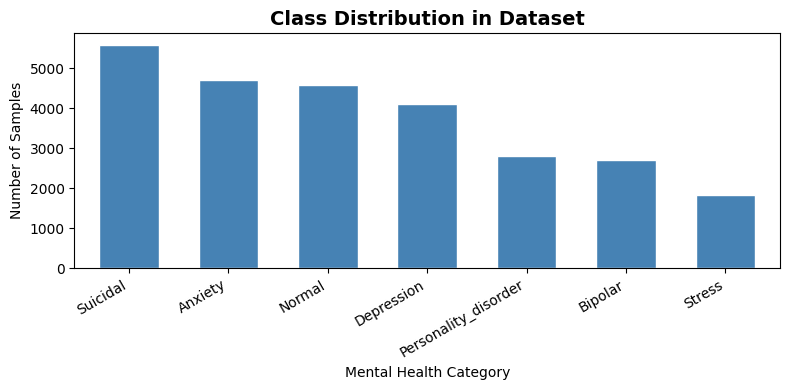

In [ ]:
# Visualise class distribution
plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white', width=0.6)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Mental Health Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 🔤 Step 3: Text Preprocessing
Pipeline: **Lowercase → Clean → Tokenize → Remove Stopwords → Lemmatize**


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full NLP preprocessing pipeline."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                 # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()             # Normalize whitespace
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print('Preprocessing text... (this may take a minute)')
df['clean_text'] = df['text'].astype(str).apply(preprocess_text)

print('\n=== Before vs After Preprocessing ===')
print(f'ORIGINAL : {df["text"].iloc[0][:200]}')
print(f'CLEANED  : {df["clean_text"].iloc[0][:200]}')
print('\n✅ Preprocessing complete!')


Preprocessing text... (this may take a minute)

=== Before vs After Preprocessing ===
ORIGINAL : Anyone else have symptoms much improved after leaving a spouse/SO I don't think I'm "better." I'm still on my meds and see my docs as appropriate, but after leaving my spouse of 15 years 9 months ago,
CLEANED  : anyone else symptom much improved leaving spouseso dont think better still med see doc appropriate leaving spouse year month ago symptom reduced almost nothing doctor able reduce medication certainly 

✅ Preprocessing complete!


## 🔢 Step 4: Encode Labels & Split Data

In [ ]:
# Encode labels
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])

NUM_CLASSES = len(le.classes_)
print(f'Classes ({NUM_CLASSES}): {list(le.classes_)}')

# Train / Val / Test split (70 / 15 / 15)
X = df['clean_text'].values
y = df['encoded_label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'\nSplit sizes:')
print(f'  Train : {len(X_train):,} samples')
print(f'  Val   : {len(X_val):,} samples')
print(f'  Test  : {len(X_test):,} samples')


Classes (7): ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality_disorder', 'Stress', 'Suicidal']

Split sizes:
  Train : 18,445 samples
  Val   : 3,952 samples
  Test  : 3,953 samples


## 🌐 Step 5: GloVe Embeddings
Download pre-trained GloVe (100d) vectors and build an embedding matrix aligned with our vocabulary.


In [ ]:
# Download GloVe pre-trained embeddings (100-dimensional)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove/
print('✅ GloVe downloaded!')



y



y
yes



✅ GloVe downloaded!


In [ ]:
# Hyperparameters
VOCAB_SIZE  = 20000   # Maximum vocabulary size
MAX_LEN     = 192     # Sequence length (truncate/pad)
EMBED_DIM   = 100     # Must match GloVe file (100d)
EPOCHS      = 20
BATCH_SIZE  = 64

# Fit tokenizer on training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Pad sequences
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'✅ Padded shape — Train: {X_train_pad.shape}, Val: {X_val_pad.shape}, Test: {X_test_pad.shape}')


✅ Padded shape — Train: (18445, 192), Val: (3952, 192), Test: (3953, 192)


In [ ]:
# Build GloVe embedding matrix
glove_embeddings = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        glove_embeddings[values[0]] = np.array(values[1:], dtype='float32')

print(f'✅ Loaded {len(glove_embeddings):,} GloVe word vectors')

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
matched, missed = 0, 0

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            matched += 1
        else:
            missed += 1

print(f'Words matched in GloVe : {matched:,}')
print(f'Words not found        : {missed:,}')
print(f'Coverage               : {matched/(matched+missed)*100:.1f}%')


✅ Loaded 400,000 GloVe word vectors
Words matched in GloVe : 17,031
Words not found        : 2,968
Coverage               : 85.2%


## 🏗️ Step 6: Build LSTM Model
Architecture: **GloVe Embedding → SpatialDropout → Bidirectional LSTM → BatchNorm → Dense Classifier**


In [ ]:
def build_lstm_model():
    model = Sequential(name='BiLSTM_GloVe')

    # GloVe embedding (fine-tunable)
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ))
    model.add(SpatialDropout1D(0.3))

    # Bidirectional LSTM
    model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.0)))

    # Classifier head
    model.add(BatchNormalization())
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Step 7: Train the Model

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='best_lstm.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

# Class weights to handle imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

# Train
print('🚀 Training Bidirectional LSTM + GloVe...')
history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('✅ Training complete!')


🚀 Training Bidirectional LSTM + GloVe...
Epoch 1/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.4199 - loss: 1.9314 - val_accuracy: 0.6420 - val_loss: 1.4273 - learning_rate: 0.0010
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6123 - loss: 1.3715 - val_accuracy: 0.7082 - val_loss: 1.0721 - learning_rate: 0.0010
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6971 - loss: 1.1070 - val_accuracy: 0.7368 - val_loss: 0.9432 - learning_rate: 0.0010
Epoch 4/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7315 - loss: 0.9498 - val_accuracy: 0.7586 - val_loss: 0.8633 - learning_rate: 0.0010
Epoch 5/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7561 - loss: 0.8354 - val_accuracy: 0.7609 - val_loss: 0.7941 - learning_rate: 0.0010
Epoch 6/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7732 - loss: 0.7511 - val_accuracy: 0.7632 - val_loss: 0.7660 - learning_rate: 0.0010
Epoch 7/20
289/289 ━━━━━━━━━━━━━━━━━━━━

## 📊 Step 8: Plot Training Curves

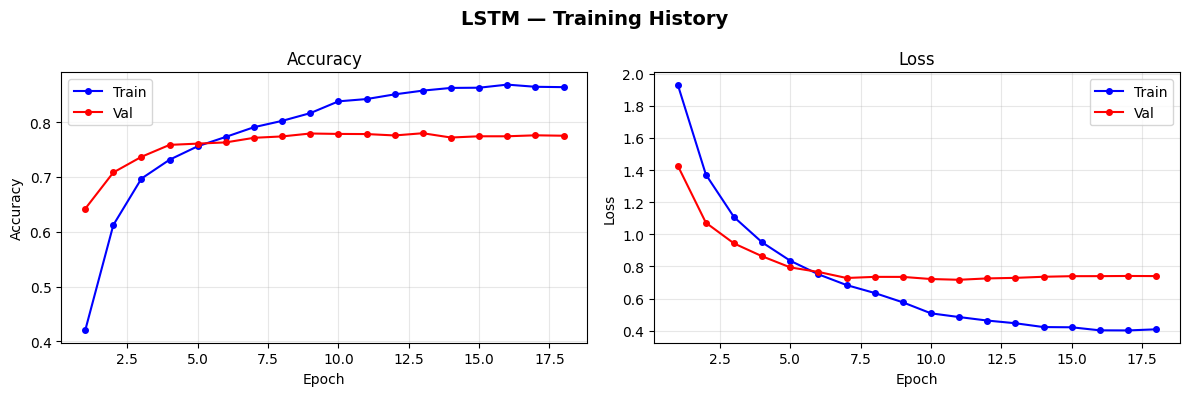

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LSTM — Training History', fontsize=14, fontweight='bold')
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],     'b-o', label='Train', markersize=4)
axes[0].plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Val',   markersize=4)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_range, history.history['loss'],     'b-o', label='Train', markersize=4)
axes[1].plot(epochs_range, history.history['val_loss'], 'r-o', label='Val',   markersize=4)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 📏 Step 9: Evaluate on Test Set

In [ ]:
# Predict
y_pred_proba = lstm_model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

avg = 'binary' if NUM_CLASSES == 2 else 'weighted'
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average=avg, zero_division=0)
rec  = recall_score(y_test, y_pred, average=avg, zero_division=0)
f1   = f1_score(y_test, y_pred, average=avg, zero_division=0)

print('──── LSTM Test Results ────')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


──── LSTM Test Results ────
  Accuracy  : 0.7885
  Precision : 0.7940
  Recall    : 0.7885
  F1-Score  : 0.7897

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.89      0.79      0.83       706
             Bipolar       0.79      0.76      0.78       408
          Depression       0.59      0.62      0.60       617
              Normal       0.97      0.98      0.97       687
Personality_disorder       0.82      0.71      0.76       422
              Stress       0.76      0.81      0.78       273
            Suicidal       0.72      0.80      0.76       840

            accuracy                           0.79      3953
           macro avg       0.79      0.78      0.78      3953
        weighted avg       0.79      0.79      0.79      3953



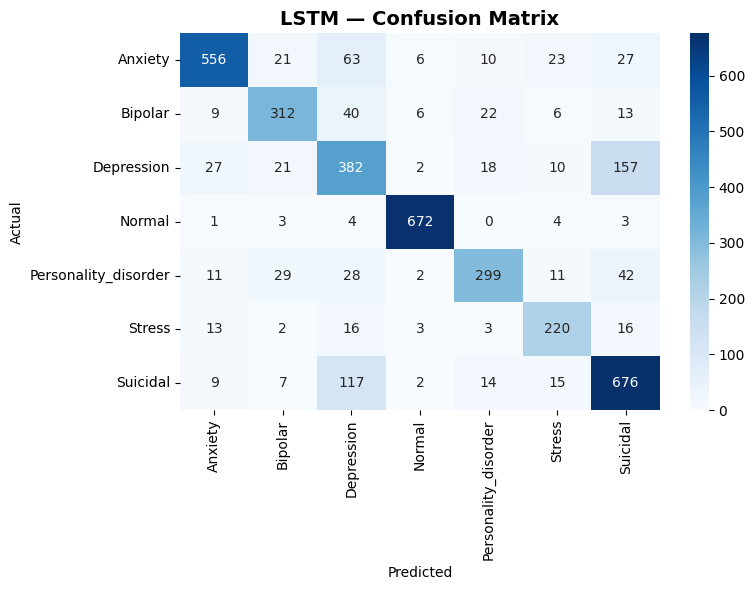

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('LSTM — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 🔮 Step 10: Live Prediction
Enter any text to predict its mental health risk category with confidence probabilities.


In [ ]:
def predict_mental_health(text, model=lstm_model):
    """Predict mental health category for a given text string."""
    cleaned = preprocess_text(str(text))
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    proba   = model.predict(padded, verbose=0)

    pred_idx    = int(np.argmax(proba, axis=1)[0])
    pred_label  = le.classes_[pred_idx]
    class_probs = {le.classes_[i]: float(proba[0][i]) for i in range(NUM_CLASSES)}

    print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  Input      : "{text[:100]}"')
    print(f'  Prediction : ✅ {pred_label.upper()}')
    print(f'  Probabilities:')
    for cls, prob in sorted(class_probs.items(), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f'    {cls:<20} {prob:.4f}  {bar}')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    return pred_label, class_probs

# Sample predictions
test_sentences = [
    "I have been feeling really hopeless lately and I don't see the point anymore.",
    "I am so grateful for my friends and family, life is beautiful!",
    "I can't sleep, I'm always anxious and my heart races for no reason.",
    "Today was a great day, I went for a hike and felt truly at peace.",
    "I keep having dark thoughts and I am struggling to get out of bed."
]

for sentence in test_sentences:
    predict_mental_health(sentence)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input      : "I have been feeling really hopeless lately and I don't see the point anymore."
  Prediction : ✅ DEPRESSION
  Probabilities:
    Depression           0.5335  ████████████████
    Suicidal             0.4335  █████████████
    Bipolar              0.0172  
    Personality_disorder 0.0067  
    Anxiety              0.0051  
    Stress               0.0039  
    Normal               0.0001  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input      : "I am so grateful for my friends and family, life is beautiful!"
  Prediction : ✅ SUICIDAL
  Probabilities:
    Suicidal             0.6686  ████████████████████
    Depression           0.2943  ████████
    Stress               0.0156  
    Bipolar              0.0104  
    Personality_disorder 0.0057  
    Anxiety              0.0052  
    Normal               0.0001  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Interactive widget — type your own text
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

LABEL_CLASSES = list(le.classes_)
BAR_COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
              '#edc948','#b07aa1','#ff9da7','#9c755f','#bab0ac']
color_map = {cls: BAR_COLORS[i % len(BAR_COLORS)] for i, cls in enumerate(LABEL_CLASSES)}

def render_results(raw_text, prediction, class_probs):
    confidence = class_probs[prediction]
    pred_color = color_map[prediction]
    bars_html = ''
    for cls, prob in sorted(class_probs.items(), key=lambda x: -x[1]):
        pct = prob * 100
        bars_html += f"""
        <div style='margin-bottom:10px;'>
          <div style='display:flex; justify-content:space-between; margin-bottom:3px;'>
            <span style='font-size:13px; font-weight:500;'>{cls}</span>
            <span style='font-size:13px; color:#555;'>{pct:.1f}%</span>
          </div>
          <div style='background:#e9ecef; border-radius:6px; height:18px; overflow:hidden;'>
            <div style='width:{pct}%; background:{color_map[cls]}; height:100%; border-radius:6px;'></div>
          </div>
        </div>"""
    return f"""
    <div style='font-family:Segoe UI,sans-serif; max-width:820px; margin:12px auto;
                border:1px solid #dee2e6; border-radius:12px; overflow:hidden;'>
      <div style='background:linear-gradient(135deg,#1a1a2e,#16213e); color:white;
                  padding:16px 22px;'>
        <h3 style='margin:0;'>🧠 Mental Health Risk Detector</h3>
        <p style='margin:4px 0 0; font-size:12px; opacity:0.7;'>Bidirectional LSTM + GloVe</p>
      </div>
      <div style='display:grid; grid-template-columns:1fr 1fr; background:#fff;'>
        <div style='padding:18px; border-right:1px solid #dee2e6;'>
          <p style='font-size:11px; font-weight:600; color:#6c757d; text-transform:uppercase;'>Input Text</p>
          <div style='background:#f8f9fa; border-radius:8px; padding:10px; font-size:13px;
                      min-height:60px; margin-bottom:16px;'>{raw_text}</div>
          <p style='font-size:11px; font-weight:600; color:#6c757d; text-transform:uppercase;'>Prediction</p>
          <div style='background:{pred_color}18; border:2px solid {pred_color}; border-radius:10px;
                      padding:12px 16px; display:flex; justify-content:space-between; align-items:center;'>
            <span style='font-size:18px; font-weight:700; color:{pred_color};'>{prediction}</span>
            <span style='font-size:20px; font-weight:700; color:{pred_color};'>{confidence:.1%}</span>
          </div>
        </div>
        <div style='padding:18px;'>
          <p style='font-size:11px; font-weight:600; color:#6c757d; text-transform:uppercase;'>Class Probabilities</p>
          {bars_html}
        </div>
      </div>
    </div>"""

text_input  = widgets.Textarea(placeholder='Enter text to analyse...', layout=widgets.Layout(width='820px', height='90px'))
analyse_btn = widgets.Button(description=' Analyse', icon='search', layout=widgets.Layout(width='130px', height='36px'), style={'button_color':'#4e79a7','font_weight':'bold'})
clear_btn   = widgets.Button(description=' Clear', icon='times', layout=widgets.Layout(width='100px', height='36px'), style={'button_color':'#e15759'})
output_area = widgets.Output()

def on_analyse(b):
    with output_area:
        clear_output(wait=True)
        raw = text_input.value.strip()
        if not raw:
            display(HTML('<p style="color:#e15759;">⚠️ Please enter some text first.</p>'))
            return
        pred, probs = predict_mental_health(raw)
        display(HTML(render_results(raw, pred, probs)))

def on_clear(b):
    text_input.value = ''
    with output_area:
        clear_output()

analyse_btn.on_click(on_analyse)
clear_btn.on_click(on_clear)
display(text_input, widgets.HBox([analyse_btn, clear_btn]), output_area)


Textarea(value='', layout=Layout(height='90px', width='820px'), placeholder='Enter text to analyse...')

Output()

## 💾 Step 11: Save Model & Artifacts

In [ ]:
# Save model
lstm_model.save('lstm_mental_health_model.h5')
print('✅ lstm_mental_health_model.h5 saved')

# Save tokenizer
with open('tokenizer.json', 'w') as f:
    json.dump(tokenizer.to_json(), f)
print('✅ tokenizer.json saved')

# Save label classes
with open('label_classes.json', 'w') as f:
    json.dump(list(le.classes_), f)
print(f'✅ label_classes.json saved → {list(le.classes_)}')


✅ lstm_mental_health_model.h5 saved
✅ tokenizer.json saved
✅ label_classes.json saved → ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality_disorder', 'Stress', 'Suicidal']


In [ ]:
# Download all saved files to your local machine
from google.colab import files

for fname in ['lstm_mental_health_model.h5', 'tokenizer.json', 'label_classes.json']:
    files.download(fname)

print('⬇️ Download triggered for all 3 files')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download triggered for all 3 files


## 📝 Step 12: Final Summary

In [ ]:
print('╔══════════════════════════════════════════════════════════╗')
print('║      MENTAL HEALTH RISK DETECTION — FINAL RESULTS        ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Model    : Bidirectional LSTM + GloVe Embeddings        ║')
print(f'║  Accuracy : {acc:.4f}                                        ║')
print(f'║  F1-Score : {f1:.4f}                                        ║')
print(f'║  Classes  : {NUM_CLASSES}                                            ║')
print('╚══════════════════════════════════════════════════════════╝')
print('''
Key Design Choices:
  • GloVe (100d)      — Pre-trained embeddings for rich word representations
  • Bidirectional LSTM — Captures both forward and backward context
  • Class weights      — Handles class imbalance in the dataset
  • Early stopping     — Prevents overfitting with best-weight restoration
  • L2 regularization  — Reduces overfitting in dense layers
''')


╔══════════════════════════════════════════════════════════╗
║      MENTAL HEALTH RISK DETECTION — FINAL RESULTS        ║
╠══════════════════════════════════════════════════════════╣
║  Model    : Bidirectional LSTM + GloVe Embeddings        ║
║  Accuracy : 0.7885                                        ║
║  F1-Score : 0.7897                                        ║
║  Classes  : 7                                            ║
╚══════════════════════════════════════════════════════════╝

Key Design Choices:
  • GloVe (100d)      — Pre-trained embeddings for rich word representations
  • Bidirectional LSTM — Captures both forward and backward context
  • Class weights      — Handles class imbalance in the dataset
  • Early stopping     — Prevents overfitting with best-weight restoration
  • L2 regularization  — Reduces overfitting in dense layers

